# Agentic Document Processing Pipeline Research Notebook

## Phase 1:: Explore processing with just OCR (Tesseract)
### Objectives:
    - parsing and extracting information from the document
    - building an agent equipped with tesseract OCR tool

    * Limitations:
    OCR converts pixels to text. OCR alone produces raw text, but without context, syntax and information coherence.

In [1]:
# Needed Libraries
# Pillow (PIL): Load and manipulate images
# Pytesseract: Python wrapper for Tesseract OCR engine
# LangChain: Framework for building tool-enabled LLM applications
# Langgraph: for building graph-based agents


from PIL import Image
import pytesseract
import zai


from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.messages import HumanMessage, SystemMessage, AnyMessage
from langgraph.prebuilt import tools_condition, ToolNode
from pydantic import BaseModel
from typing_extensions import Annotated
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
import os

from langchain.tools import tool

load_dotenv()


/Users/chibuikeiwuchukwu/Docs/Real_ML_Project/agents_project/agent_env/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/chibuikeiwuchukwu/Docs/Real_ML_Project/agents_project/agent_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# Define tool

In [2]:
path = os.getcwd()
print(path)
path_dir =  os.path.join(os.getcwd(), 'adam')
print(path_dir)

/Users/chibuikeiwuchukwu/Docs/Real_ML_Project/agents_project/adp
/Users/chibuikeiwuchukwu/Docs/Real_ML_Project/agents_project/adp/adam


In [3]:
# create the ocr tool
@tool
def read_image_with_ocr(image_file:str) -> str:
    """ read an image using ocr and extract the texts """
    from PIL import Image
    # read current working directory
    image_path = os.path.join(os.getcwd(), image_file)
    try:
        text =  pytesseract.image_to_string(image = Image.open(image_path))
        return text
    except Exception as e:
        return f"error reading image: {e}"

tools = [read_image_with_ocr]

In [4]:
# confirming the function tool works
# provide a path to an image file
data_file = 'receipt.png'
image_text = read_image_with_ocr.run(data_file)
print('raw ocr output:\n\n', image_text)

raw ocr output:

 CONSTRUCTION RECEIPT TEMPLATE

EXAMPLE Blank invoice can be found on the next tab.

‘Company Name
123 Main Street
Hamitton, OH 44416
(321) 456-7890,
Email Address

CLIENT

ATIN: Name / Dept
‘Company Name

123 Main Street
Hamitton, OH 44416
(321) 456-7890
Email Address
ary MATERIAL RATE ToraL
‘Marking of foundation
5 layout at ste 700.00 ¥,000.00
ath excavation up to
4 | therequred depth by 15000 600.00
machine
Earth excavation and
2 | levelingofsolbyhand- 12500 280.00
‘operated tools
15 Placing of PCC 78.00 1,170.00
Placement of
$0 reinforcement stee! 165.00 4950.00
Erection of concrete
4 Foxmworks for footings 280.00 7820.0
TOTALMATERIAIS $15,790.00
MISCELANEOUS CHARGES
Transportation of materials 430,00
Consuitations with architect 760.00
TOTALMISCELANEOUS —§ 1,190.00
[CUSTOMER SIGNATURE Date
(00/00/0000
[AUTHORIZED SIGNATURE Date
(00/00/0000

ing this invoice, please contact

Name, (321) 456-7890, Emal Address

www:yourwebaddress.com

RECEIPT
DATE OF NVOICE INVOICE

# Define the LLM

In [5]:
OLLAMA_API_KEY = os.getenv('OLLAMA_API_KEY')

llm = ChatOllama(
    client_kwargs={
                    'headers':{'Authorization': f"Bearer {OLLAMA_API_KEY}"}
                },
    model='gpt-oss:20b-cloud',
    reasoning=True,
    temperature = 0,
    base_url="https://ollama.com"
)

# bind out tool to the llm
llm_with_tool  = llm.bind_tools(tools)

# Agent development

In [6]:
# define agent's state
class InternalState(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]

In [7]:
# create agent graph and compile
graph = StateGraph(InternalState)

# define a basic agent function
def basic_agent(state: InternalState):
    system_prompt = SystemMessage(
        content= f"""
        you are my personal assistant. process image document using the tool 'read_image_with_ocr'. Answer questions using the document as
        source of truth for information"""
    )
    message =  state.messages
    response = llm_with_tool.invoke([system_prompt] + message)
    return {'messages': state.messages + [response]}

# add nodes
graph.add_node('agent', basic_agent)
graph.add_node('tools', ToolNode(tools))

# define graph logic
graph.add_edge(START, 'agent')
graph.add_conditional_edges('agent', tools_condition)
graph.add_edge('tools', 'agent')


# comiple graph
compiled_ocr_agent_graph = graph.compile()


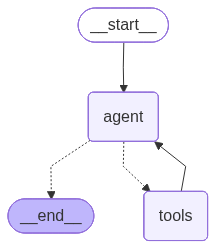

In [8]:
# display graph
from IPython.display import display, Image
display(Image(compiled_ocr_agent_graph.get_graph().draw_mermaid_png()))

In [9]:
response = compiled_ocr_agent_graph.invoke({'messages': HumanMessage(content='how many hours is required for foundation layout at site as seen in receipt.png')})

In [10]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

how many hours is required for foundation layout at site as seen in receipt.png
================================== Ai Message ==================================
Tool Calls:
  read_image_with_ocr (56be24a5-b9ca-45ef-b945-b5032d8e24e8)
 Call ID: 56be24a5-b9ca-45ef-b945-b5032d8e24e8
  Args:
    image_file: receipt.png
================================= Tool Message =================================
Name: read_image_with_ocr

CONSTRUCTION RECEIPT TEMPLATE

EXAMPLE Blank invoice can be found on the next tab.

‘Company Name
123 Main Street
Hamitton, OH 44416
(321) 456-7890,
Email Address

CLIENT

ATIN: Name / Dept
‘Company Name

123 Main Street
Hamitton, OH 44416
(321) 456-7890
Email Address
ary MATERIAL RATE ToraL
‘Marking of foundation
5 layout at ste 700.00 ¥,000.00
ath excavation up to
4 | therequred depth by 15000 600.00
machine
Earth excavation and
2 | levelingofsolbyhand- 12500 280.00
‘operated tools
15 P

from the above, we can see that the basic agent using pytesseract ocr wasn't good enough

## Phase 2:: Explore processing with TrOCR
### Objectives:
    - Use TrOCR for text detection and text recognition
    - Use TrOCR for layout detection to identify regions of interest
    - building an agent equipped with PaddleOCR tool

### Technology:
    - Uses deep neural network model

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [12]:
from PIL import Image


In [14]:
from glmocr import parse

In [15]:
parse?

Signature:
parse(
    images: Union[str, bytes, pathlib.Path, List[Union[str, bytes, pathlib.Path]]],
    config_path: Optional[str] = None,
    save_layout_visualization: bool = True,
    *,
    stream: bool = False,
    preserve_order: bool = True,
    api_key: Optional[str] = None,
    api_url: Optional[str] = None,
    model: Optional[str] = None,
    mode: Optional[str] = None,
    timeout: Optional[int] = None,
    log_level: Optional[str] = None,
    env_file: Optional[str] = None,
    **kwargs: Any,
) -> Union[glmocr.parser_result.pipeline_result.PipelineResult, List[glmocr.parser_result.pipeline_result.PipelineResult], Generator[glmocr.parser_result.pipeline_result.PipelineResult, NoneType, NoneType]]
Docstring:
Convenience function: parse images or documents in one call.

Creates a :class:`GlmOcr` instance, runs parsing, and cleans up.

Examples::

    import glmocr

    # Minimal – only needs ZHIPU_API_KEY env var
    results = glmocr.parse("image.png")

    # Explicit API k

In [21]:
data = os.path.join(os.getcwd(), "receipt.png")
result = parse(images = data, mode="selfhosted")
result.save(output_dir="./results")

Starting Pipeline...
Loading weights: 100%|██████████| 858/858 [00:00<00:00, 14608.72it/s]
Pipeline started!
GLM-OCR initialized in self-hosted mode
Stopping Pipeline...
Pipeline stopped!


In [23]:
result?

Type:           PipelineResult
String form:    PipelineResult(images=1)
File:           ~/Docs/Real_ML_Project/agents_project/agent_env/lib/python3.12/site-packages/glmocr/parser_result/pipeline_result.py
Docstring:     
Pipeline result for one input unit (one image or one PDF).

Supports saving JSON, Markdown, and optional layout visualization.
Init docstring:
Initialize.

Args:
    json_result: JSON result (string, dict, or list).
    markdown_result: Markdown result.
    original_images: Original image paths for this unit.
    image_files: Mapping of ``filename`` → PIL Image for image-type
        regions; saved directly to ``imgs/`` during :meth:`save`.
    raw_json_result: Raw model output before post-processing (optional).
    layout_vis_images: Mapping of ``page_idx`` → PIL Image for layout
        visualization; saved to ``layout_vis/`` during :meth:`save`.

In [24]:
json_file = result.json_result
json_file

[[{'index': 0,
   'label': 'text',
   'bbox_2d': [16, 2, 551, 26],
   'polygon': [[21, 2], [21, 25], [549, 25], [549, 2]],
   'content': '## 境',
   'native_label': 'paragraph_title'},
  {'index': 1,
   'label': 'text',
   'bbox_2d': [17, 35, 477, 52],
   'polygon': [[22, 35], [22, 52], [475, 52], [475, 35]],
   'content': '境',
   'native_label': 'text'},
  {'index': 2,
   'label': 'text',
   'bbox_2d': [21, 61, 270, 85],
   'polygon': [[21, 66], [21, 70], [26, 84], [268, 84], [268, 61], [26, 61]],
   'content': '## 境',
   'native_label': 'paragraph_title'},
  {'index': 3,
   'label': 'text',
   'bbox_2d': [25, 86, 190, 151],
   'polygon': [[25, 86],
    [25, 151],
    [189, 151],
    [189, 92],
    [180, 86],
    [155, 86],
    [119, 86],
    [116, 86],
    [110, 86]],
   'content': '境',
   'native_label': 'text'},
  {'index': 4,
   'label': 'text',
   'bbox_2d': [25, 183, 91, 197],
   'polygon': [[25, 183], [25, 196], [90, 196], [90, 183]],
   'content': '## 境',
   'native_label': 'pa